# MCDI500 — Fase 3 (Sumativa): Núcleo algorítmico, eficiencia e implementación orientada a objetos

**Proyecto:** Análisis predictivo de diabetes  
**Integrantes:** Daniel Hormazábal, Cristian Pasten, Enso Guidotti  
**Curso:** MCDI500 — Herramientas de software científico  
**Docente:** Omar Salinas Silva  
**Fecha:** 17-06-2026  

---

## Descripción

Este notebook implementa el núcleo algorítmico de la Fase 3, integrando el pipeline de preprocesamiento de la Fase 2 con Programación Orientada a Objetos (herencia, polimorfismo y encapsulamiento), programación recursiva y mediciones formales de complejidad con `timeit`. Se construye sobre los datos procesados en F2 y extiende el análisis exploratorio de la Formativa 3 (UNAB, 2026a).

---

## Tabla de contenidos

1. [Importación y configuración](#seccion-1)
2. [Carga del dataset procesado (F2)](#seccion-2)
3. [Pipeline POO: herencia y polimorfismo](#seccion-3)
4. [Validación técnica del pipeline](#seccion-4)
5. [Clase AnalizadorDiabetes (análisis exploratorio)](#seccion-5)
6. [Ranking recursivo: merge sort](#seccion-6)
7. [Mediciones de complejidad con timeit](#seccion-7)
8. [Comparación de implementaciones](#seccion-8)
9. [Documentación de arquitectura](#seccion-9)
10. [Resumen y proyección](#seccion-10)


<a id="seccion-1"></a>

---
## 1. Importación y configuración

Se utilizan las librerías del entorno reproducible de F1 y F2, incorporando `timeit` para mediciones formales de complejidad, `tracemalloc` para complejidad espacial y `abc` para la jerarquía de clases (McKinney, 2022).

In [35]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timeit
import tracemalloc
import os

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print("\nLibrerías importadas correctamente ✓")
print("Módulos POO: abc.ABC, abc.abstractmethod disponibles ✓")


pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4

Librerías importadas correctamente ✓
Módulos POO: abc.ABC, abc.abstractmethod disponibles ✓


<a id="seccion-2"></a>

---
## 2. Carga del dataset procesado (F2)

Se carga directamente el archivo `data/processed/diabetes_clean.csv` generado en la Fase 2. Este dataset tiene 15.000 registros × 9 columnas, con las 8 variables predictoras normalizadas en [0, 1] y la columna `PatientID` excluida (UNAB, 2026b).

In [36]:
def cargar_dataset(ruta):
    """
    Carga el dataset.

    Parámetros
    ----------
    ruta :Ruta al archivo CSV.

    Retorna
    -------
    pd.DataFrame — Dataset listo para análisis.
    """
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró: {ruta}")
    df = pd.read_csv(ruta)
    # Verificaciones básicas de integridad
    assert 'Diabetic' in df.columns, "ERROR: falta la variable objetivo Diabetic"
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas ✓")
    print(f"Columnas  : {df.columns.tolist()}")
    print(f"Nulos     : {df.isnull().sum().sum()}")
    print(f"Diabetic  : {df['Diabetic'].value_counts().to_dict()}")
    return df

df_raw = cargar_dataset('../../data/raw/diabetes.csv')

FEATURES = ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']
TARGET   = 'Diabetic'
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")


Dataset cargado: 15,000 filas × 10 columnas ✓
Columnas  : ['PatientID', 'Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age', 'Diabetic']
Nulos     : 0
Diabetic  : {0: 10000, 1: 5000}

Features (8): ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']


<a id="seccion-3"></a>

---
## 3. Pipeline POO: herencia, polimorfismo y encapsulamiento

### Justificación del diseño

En la Fase 2, el preprocesamiento se implementó como funciones independientes. En la Fase 3, se refactoriza a una **jerarquía de clases** que aplica los tres principios de POO (VanderPlas, 2023):

- **Encapsulamiento**: `_etapas` vive protegido en `Pipeline`; `_df` y `_resultados` en `AnalizadorDiabetes`.
- **Herencia**: cada transformación concreta hereda de `Transformador` (clase base abstracta).
- **Polimorfismo**: `Pipeline` llama `aplicar(df)` sobre cualquier transformador sin saber cuál es.

Las clases viven en `src/analizador.py` como módulo reutilizable, importable desde cualquier notebook del proyecto. El pipeline opera sobre `data/raw/diabetes.csv` (datos crudos), demostrando transformaciones efectivas: `PatientID` presente y excluido, posibles duplicados detectados, NaN imputados con mediana y features normalizadas desde valores clínicos originales.

### Arquitectura

```
src/analizador.py
├── Transformador (ABC)      ← contrato común
│   ├── ExcluirColumna       ← herencia
│   ├── EliminarDuplicados   ← herencia
│   ├── ImputarMediana       ← herencia
│   └── NormalizarMinMax     ← herencia
├── Pipeline                 ← composición + polimorfismo
└── AnalizadorDiabetes       ← encapsulamiento + caché
```


In [37]:
#  IMPORTAR MÓDULO REUTILIZABLE DESDE src/ Analizador.py
# Asegurar que src/ esté en sys.path (robusto para distintas carpetas de ejecución)
for rel in (os.path.join('..', '..', 'src'), os.path.join('..', 'src'), 'src'):
    ruta_src = os.path.abspath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(ruta_src) and ruta_src not in sys.path:
        sys.path.insert(0, ruta_src)

# Importar módulo reutilizable con clases de transformación y análisis
    from Analizador import (
        Transformador,
        ExcluirColumna,
        EliminarDuplicados,
        ImputarMediana,
        NormalizarMinMax,
        Pipeline,
        AnalizadorDiabetes,
    )

print("Módulo src/Analizador.py importado correctamente ✓")
print()
print("Clases disponibles:")
for cls in [Transformador, ExcluirColumna, EliminarDuplicados,
            ImputarMediana, NormalizarMinMax, Pipeline, AnalizadorDiabetes]:
    print(f"  ✓ {cls.__name__}")


Módulo src/Analizador.py importado correctamente ✓

Clases disponibles:
  ✓ Transformador
  ✓ ExcluirColumna
  ✓ EliminarDuplicados
  ✓ ImputarMediana
  ✓ NormalizarMinMax
  ✓ Pipeline
  ✓ AnalizadorDiabetes


In [38]:
# EJECUCIÓN DEL PIPELINE SOBRE DATOS CRUDOS 
pipeline = Pipeline([
    ExcluirColumna('PatientID'),   # elimina identificador sin valor predictivo
    EliminarDuplicados(),          # garantiza integridad: un registro por paciente
    ImputarMediana(),              # imputa NaN con mediana (robusta a outliers)
    NormalizarMinMax(),            # escala features a [0, 1]
])

print("Etapas del pipeline:")
pipeline.listar_etapas()
print()

# Ejecutar sobre el dataset CRUDO — transformaciones efectivas
df_pipeline = pipeline.ejecutar(df_raw.copy())

# El dataset resultante equivale al diabetes_clean.csv de F2
df = df_pipeline.copy()
print(f"\nDataset procesado listo para análisis:")
print(f"  Filas     : {df.shape[0]:,}")
print(f"  Columnas  : {df.shape[1]}")
print(f"  Nulos     : {df.isnull().sum().sum()}")
print(f"  Rango     : [{df[FEATURES].min().min():.4f}, {df[FEATURES].max().max():.4f}]")

Etapas del pipeline:
  1. ExcluirColumna()
  2. EliminarDuplicados()
  3. ImputarMediana()
  4. NormalizarMinMax()

Pipeline iniciado — 4 etapas

Etapa 1/4: ExcluirColumna()
  [ExcluirColumna] 'PatientID' excluida ✓
Etapa 2/4: EliminarDuplicados()
  [EliminarDuplicados] 0 duplicados eliminados ✓
Etapa 3/4: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 4/4: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  15,000 × 9

Dataset procesado listo para análisis:
  Filas     : 15,000
  Columnas  : 9
  Nulos     : 0
  Rango     : [0.0000, 1.0000]


<a id="seccion-4"></a>

---
## 4. Validación técnica del pipeline

Se verifican tres escenarios según las buenas prácticas de testing (Ramalho, 2022):

- **Caso normal**: dataset estándar, el pipeline ejecuta sin errores.
- **Caso límite**: columna a excluir no existe, una sola fila, columna constante.
- **Excepción**: etapa inválida en el pipeline lanza `TypeError` controlado.


In [39]:
# CASO NORMAL
print("TEST 1 — Caso normal\n")
df_test = df.copy()
pipe_test = Pipeline([ImputarMediana(), NormalizarMinMax()])
df_resultado = pipe_test.ejecutar(df_test)

# Verificaciones básicas
assert df_resultado.isnull().sum().sum() == 0, "ERROR: hay nulos"
assert df_resultado.shape[0] == len(df), "ERROR: se perdieron filas"
assert set(df_resultado['Diabetic'].unique()) == {0, 1}, "ERROR: target inválido"
print(f"\n✓ Caso normal: {df_resultado.shape}, 0 nulos, target válido")

# CASO LÍMITE 1: columna a excluir no existe 
print("\nTEST 2 — Caso límite: columna inexistente\n")
pipe_limite = Pipeline([ExcluirColumna('ColumnaQueNoExiste')])
df_limite = pipe_limite.ejecutar(df.copy())
assert df_limite.shape == df.shape, "ERROR: el shape cambió"
print(f"✓ Columna inexistente manejada sin error: shape {df_limite.shape}")

# CASO LÍMITE 2: dataset de una sola fila 
print("\nTEST 3 — Caso límite: dataset de 1 fila\n")

df_una_fila = df.iloc[:1].copy()
pipe_una = Pipeline([ImputarMediana(), NormalizarMinMax()])
df_una_resultado = pipe_una.ejecutar(df_una_fila)
assert len(df_una_resultado) == 1
print(f"✓ Dataset de 1 fila procesado correctamente: {df_una_resultado.shape}")

# CASO LÍMITE 3: columna constante (rango = 0) 
print("\nTEST 4 — Caso límite: columna constante\n")
df_constante = df.copy()
df_constante['BMI'] = 0.5  # columna constante → rango = 0
pipe_const = Pipeline([NormalizarMinMax()])
df_const_resultado = pipe_const.ejecutar(df_constante)
# La columna constante no debe generar NaN (división por cero protegida)
assert df_const_resultado['BMI'].isnull().sum() == 0
print(f"✓ Columna constante procesada sin NaN: BMI={df_const_resultado['BMI'].unique()}")

# EXCEPCIÓN: etapa inválida 
print("\nTEST 5 — Excepción: etapa no es Transformador\n")
try:
    pipe_invalido = Pipeline(["esto no es un transformador"])
except TypeError as e:
    print(f"✓ TypeError capturado correctamente: {e}")

print("\n Todos los tests pasados")


TEST 1 — Caso normal

Pipeline iniciado — 2 etapas

Etapa 1/2: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 2/2: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  15,000 × 9

✓ Caso normal: (15000, 9), 0 nulos, target válido

TEST 2 — Caso límite: columna inexistente

Pipeline iniciado — 1 etapas

Etapa 1/1: ExcluirColumna()
  [ExcluirColumna] 'ColumnaQueNoExiste' no encontrada — omitida

Pipeline completado ✓  →  15,000 × 9
✓ Columna inexistente manejada sin error: shape (15000, 9)

TEST 3 — Caso límite: dataset de 1 fila

Pipeline iniciado — 2 etapas

Etapa 1/2: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 2/2: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  1 × 9
✓ Dataset de 1 fila procesado correctamente: (1, 9)

TEST 4 — Caso límite: columna constante

Pipeline iniciado — 1 etapas

Etapa 1/1: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas 

<a id="seccion-5"></a>

---
## 5. Clase `AnalizadorDiabetes` (análisis exploratorio)

La clase `AnalizadorDiabetes` extiende el trabajo de la Formativa 3 con encapsulamiento más riguroso: el DataFrame se almacena como atributo protegido `_df` y los resultados se acumulan en `_resultados`. Esta clase complementa el pipeline de preprocesamiento enfocándose en el análisis estadístico del dataset ya procesado (UNAB, 2026a).

In [40]:
# AnalizadorDiabetes importado desde src/analizador.py
# Instanciar con el dataset procesado por el Pipeline
analizador = AnalizadorDiabetes(df_pipeline, FEATURES, TARGET)

AnalizadorDiabetes inicializado ✓
  Filas    : 15,000
  Features : 8
  Target   : 'Diabetic'


In [41]:
# Ejecutar análisis estadístico
stats = analizador.calcular_estadisticos_por_clase()
cols  = ['Media (No diabético)', 'Media (Diabético)', 'Δ Media (1-0)']
print("Estadísticos por clase (ordenado por poder discriminativo):\n")
print(stats[cols].sort_values('Δ Media (1-0)', ascending=False).to_string())

mejor = stats['Δ Media (1-0)'].idxmax()
print(f"\nVariable más discriminativa: {mejor} (Δ={stats.loc[mejor, 'Δ Media (1-0)']:.4f})")


Estadísticos por clase (ordenado por poder discriminativo):

                        Media (No diabético)  Media (Diabético)  Δ Media (1-0)
Feature                                                                       
Pregnancies                           0.1606             0.3698         0.2092
Age                                   0.1109             0.2678         0.1569
BMI                                   0.3134             0.4286         0.1152
SerumInsulin                          0.1281             0.2171         0.0890
DiabetesPedigree                      0.1239             0.1853         0.0614
PlasmaGlucose                         0.4119             0.4706         0.0587
TricepsThickness                      0.2354             0.2902         0.0548
DiastolicBloodPressure                0.4961             0.5310         0.0349

Variable más discriminativa: Pregnancies (Δ=0.2092)


In [42]:
# Detección de outliers
outliers = analizador.detectar_outliers_iqr()
print("Detección de outliers (IQR):\n")
print(outliers[['N Outliers', '% Outliers', 'Lím. Inf', 'Lím. Sup']] 
      .sort_values('N Outliers', ascending=False).to_string())
print(f"\nVariable con más outliers: {outliers['N Outliers'].idxmax()} "
      f"({outliers['N Outliers'].max()} — {outliers['% Outliers'].max():.2f}%)")


Detección de outliers (IQR):

                        N Outliers  % Outliers  Lím. Inf  Lím. Sup
Feature                                                           
Age                           1019        6.79   -0.3304    0.5982
SerumInsulin                   666        4.44   -0.2662    0.5287
DiabetesPedigree               475        3.17   -0.2960    0.5649
TricepsThickness                31        0.21   -0.3605    0.8488
DiastolicBloodPressure           0        0.00   -0.0699    1.0914
PlasmaGlucose                    0        0.00   -0.1858    1.0304
Pregnancies                      0        0.00   -0.6429    1.0714
BMI                              0        0.00   -0.6328    1.2703

Variable con más outliers: Age (1019 — 6.79%)


Correlación con Diabetic:

Pregnancies               0.4073
Age                       0.3426
SerumInsulin              0.2474
BMI                       0.2105
DiabetesPedigree          0.1703
TricepsThickness          0.1525
PlasmaGlucose             0.1280
DiastolicBloodPressure    0.0913


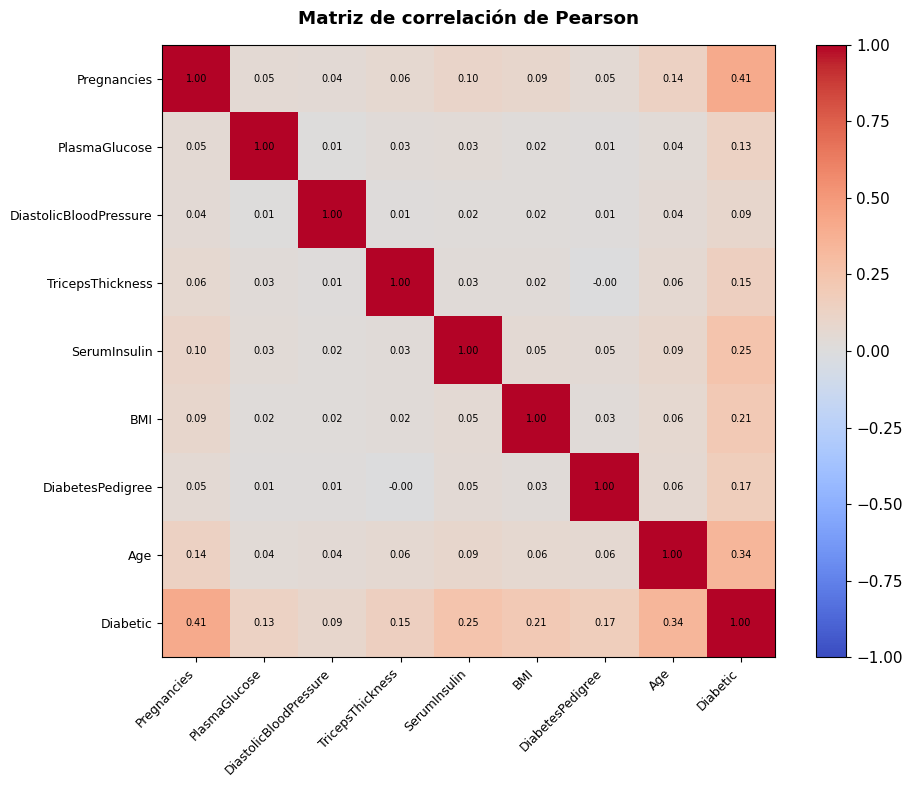

In [43]:
# Correlaciones y distribuciones
matriz_corr = analizador.calcular_correlaciones()
corr_target = matriz_corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlación con Diabetic:\n")
print(corr_target.to_string())

# Mapa de calor
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(matriz_corr.columns)))
ax.set_yticks(range(len(matriz_corr.columns)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(matriz_corr.columns, fontsize=9)
for i in range(len(matriz_corr)):
    for j in range(len(matriz_corr.columns)):
        ax.text(j, i, f"{matriz_corr.values[i,j]:.2f}",
                ha='center', va='center', fontsize=7)
ax.set_title('Matriz de correlación de Pearson', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



<a id="seccion-6"></a>

---
## 6. Ranking recursivo: merge sort

Se implementa un **merge sort recursivo** para ordenar las features por correlación absoluta con la variable objetivo. Complejidad: **O(p·log p)**.

- **Caso base**: lista de 0 o 1 elementos — ya está ordenada.
- **Caso recursivo**: dividir en dos mitades, ordenar cada una y combinar.

Esta elección se justifica algorítmicamente: un ordenamiento iterativo ingenuo es O(p²). Con 8 features la diferencia no es dramática, pero escalaría mejor con datasets de alta dimensionalidad (UNAB, 2026a).

Ranking (merge sort recursivo):

                     Feature  Correlación  |Correlación|
Rank                                                    
1                Pregnancies       0.4073         0.4073
2                        Age       0.3426         0.3426
3               SerumInsulin       0.2474         0.2474
4                        BMI       0.2105         0.2105
5           DiabetesPedigree       0.1703         0.1703
6           TricepsThickness       0.1525         0.1525
7              PlasmaGlucose       0.1280         0.1280
8     DiastolicBloodPressure       0.0913         0.0913


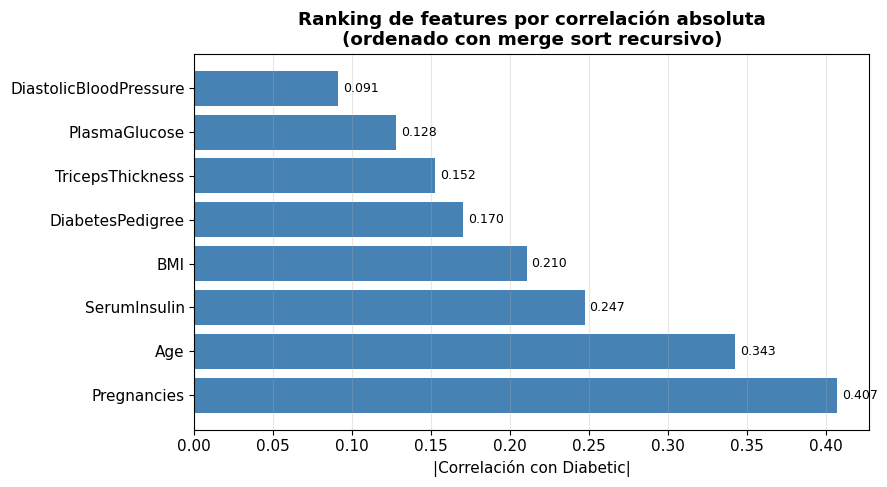

In [44]:
# Ejecutar ranking (usa los @staticmethod internos de AnalizadorDiabetes)
ranking = analizador.rankear_variables_recursivo()
print("Ranking (merge sort recursivo):\n")
print(ranking.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['steelblue' if v >= 0 else 'coral' for v in ranking['Correlación']]
ax.barh(ranking['Feature'], ranking['|Correlación|'], color=colores)
ax.set_xlabel('|Correlación con Diabetic|')
ax.set_title('Ranking de features por correlación absoluta\n(ordenado con merge sort recursivo)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(ranking['|Correlación|']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

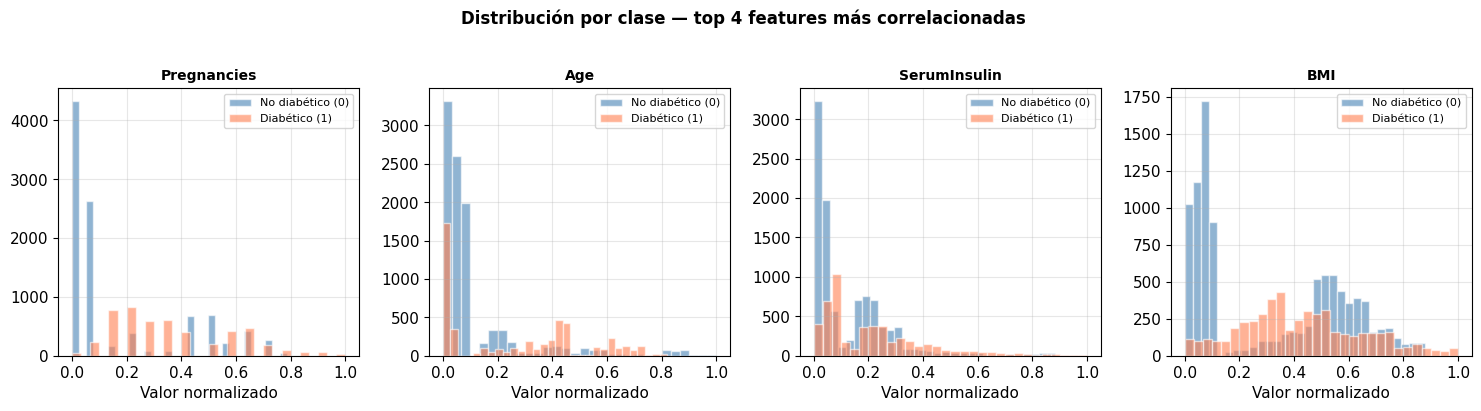

In [45]:
# Visualización de distribuciones por clase para las top 4 variables más correlacionadas
analizador.comparar_distribuciones_por_clase(n_top=4)

<a id="seccion-7"></a>

---
## 7. Mediciones de complejidad con `timeit`

Se utilizan mediciones reproducibles con `timeit` — herramienta estándar de Python para benchmarking — sobre cinco tamaños de dataset. Esto permite verificar empíricamente las complejidades teóricas declaradas (UNAB, 2026b).

In [46]:
def medir_con_timeit(df, features, target, tamanos = None, n_rep = 3):
    """
    Mide el tiempo de cada método del AnalizadorDiabetes con timeit.

    Se promedian n_rep repeticiones para reducir varianza de las mediciones.
    Complejidades esperadas:
    - calcular_estadisticos_por_clase: O(n·p)
    - detectar_outliers_iqr:           O(n·p)
    - calcular_correlaciones:          O(n·p²)
    - rankear_variables_recursivo:     O(p·log p)
    - Pipeline.ejecutar:               O(n·p)
    """
    if tamanos is None:
        tamanos = [1000, 3000, 6000, 10000, 15000]

    registros = []

    for n in tamanos:
        df_sub = df.iloc[:n].copy()

        # Medir estadísticos — O(n·p)
        t_stats = timeit.timeit(
            lambda: AnalizadorDiabetes(df_sub, features, target)
                    .calcular_estadisticos_por_clase(),
            number=n_rep
        ) / n_rep

        # Medir outliers IQR — O(n·p)
        t_iqr = timeit.timeit(
            lambda: AnalizadorDiabetes(df_sub, features, target)
                    .detectar_outliers_iqr(),
            number=n_rep
        ) / n_rep

        # Medir correlaciones — O(n·p²)
        t_corr = timeit.timeit(
            lambda: AnalizadorDiabetes(df_sub, features, target)
                    .calcular_correlaciones(),
            number=n_rep
        ) / n_rep

        # Medir ranking recursivo — O(p·log p)
        az_temp = AnalizadorDiabetes(df_sub, features, target)
        az_temp.calcular_correlaciones()
        t_rank = timeit.timeit(
            lambda: az_temp.rankear_variables_recursivo(),
            number=n_rep
        ) / n_rep

        # Medir pipeline completo — O(n·p)
        t_pipe = timeit.timeit(
            lambda: Pipeline([EliminarDuplicados(), ImputarMediana(), NormalizarMinMax()]).ejecutar(df_sub.copy()),
            number=n_rep
        ) / n_rep

        registros.append({
            'N': n,
            'Stats O(n·p) ms':    round(t_stats * 1000, 2),
            'IQR O(n·p) ms':      round(t_iqr * 1000, 2),
            'Corr O(n·p²) ms':    round(t_corr * 1000, 2),
            'Rank O(p·log p) ms': round(t_rank * 1000, 3),
            'Pipeline O(n·p) ms': round(t_pipe * 1000, 2),
        })
        print(f"  n={n:<6} stats={t_stats*1000:.1f}ms  iqr={t_iqr*1000:.1f}ms  corr={t_corr*1000:.1f}ms  rank={t_rank*1000:.2f}ms  pipe={t_pipe*1000:.1f}ms")

    return pd.DataFrame(registros).set_index('N')


print("Midiendo complejidad temporal con timeit (n_rep=3)...\n")
df_tiempos = medir_con_timeit(df_pipeline, FEATURES, TARGET, n_rep=3)
print("\nTabla de tiempos promedio (ms):")
print(df_tiempos.to_string())


Midiendo complejidad temporal con timeit (n_rep=3)...

AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
AnalizadorDiabetes inicializado ✓
  Filas    : 1,000
  Features : 8
  Target   : 'Diabetic'
Pipeline iniciado — 3 eta

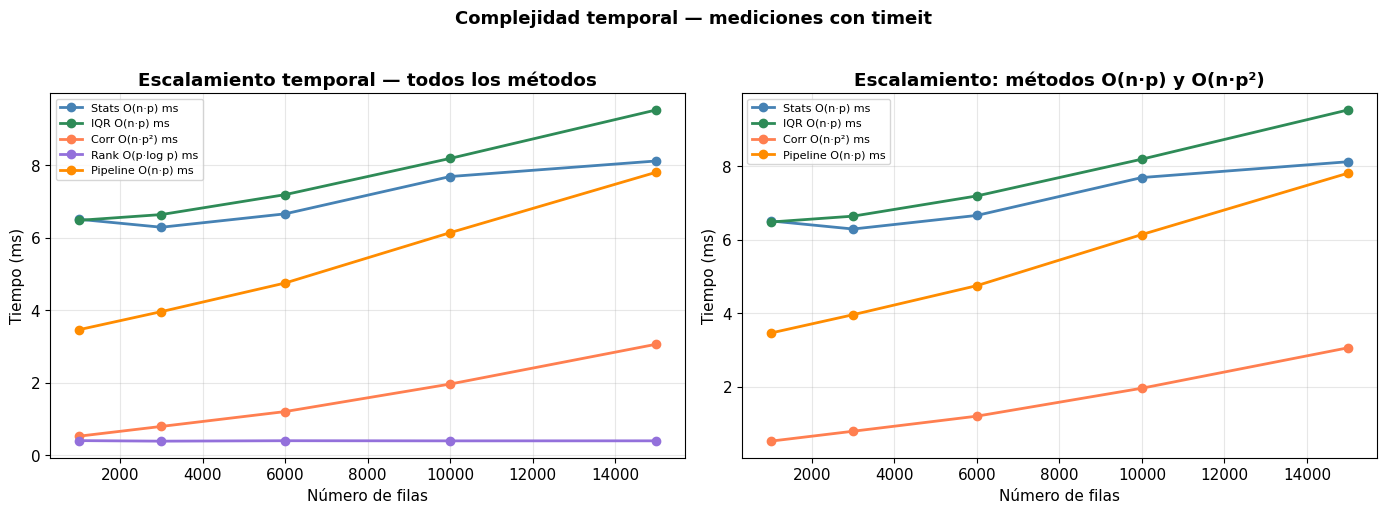

In [47]:
# Visualización del escalamiento temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = {
    'Stats O(n·p) ms':    'steelblue',
    'IQR O(n·p) ms':      'seagreen',
    'Corr O(n·p²) ms':    'coral',
    'Rank O(p·log p) ms': 'mediumpurple',
    'Pipeline O(n·p) ms': 'darkorange',
}

# Gráfico izquierdo: todos los métodos
for col, color in colores.items():
    axes[0].plot(df_tiempos.index, df_tiempos[col], 'o-', label=col, color=color, linewidth=2)
axes[0].set_title('Escalamiento temporal — todos los métodos', fontweight='bold')
axes[0].set_xlabel('Número de filas')
axes[0].set_ylabel('Tiempo (ms)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfico derecho: solo los lineales (sin rank que es casi constante)
for col in ['Stats O(n·p) ms', 'IQR O(n·p) ms', 'Corr O(n·p²) ms', 'Pipeline O(n·p) ms']:
    axes[1].plot(df_tiempos.index, df_tiempos[col],'o-', label=col, color=colores[col], linewidth=2)
axes[1].set_title('Escalamiento: métodos O(n·p) y O(n·p²)', fontweight='bold')
axes[1].set_xlabel('Número de filas')
axes[1].set_ylabel('Tiempo (ms)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Complejidad temporal — mediciones con timeit', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="seccion-8"></a>

---
## 8. Comparación de implementaciones: iterativo vs vectorizado

Se comparan dos implementaciones del mismo cálculo estadístico para demostrar la diferencia de eficiencia entre un enfoque iterativo (bucle fila por fila) y uno vectorizado (operaciones sobre arrays). Esta comparación evidencia el impacto de las decisiones de implementación en la eficiencia computacional (VanderPlas, 2023).

In [48]:
# IMPLEMENTACIÓN A: bucle iterativo (fila por fila) 
def calcular_media_iterativo(df, col):
    """
    Calcula la media de una columna iterando fila por fila.
    Complejidad: O(n) — pero con overhead de Python por fila.
    """
    total = 0.0
    n = 0
    for valor in df[col]:   # iteración explícita
        total += valor
        n += 1
    return total / n if n > 0 else 0.0


# IMPLEMENTACIÓN B: vectorizado con NumPy 
def calcular_media_vectorizado(df, col):
    """
    Calcula la media con operación vectorizada de NumPy.
    Complejidad: O(n) — misma complejidad teórica, menor overhead.
    """
    return df[col].mean()  # operación vectorizada nativa de pandas/numpy


# MEDICIÓN CON timeit
col_test = 'PlasmaGlucose'
n_reps   = 50

t_iter = timeit.timeit(
    lambda: calcular_media_iterativo(df_pipeline, col_test),
    number=n_reps
) / n_reps

t_vect = timeit.timeit(
    lambda: calcular_media_vectorizado(df_pipeline, col_test),
    number=n_reps
) / n_reps

# Verificar que ambas implementaciones producen el mismo resultado
r_iter = calcular_media_iterativo(df_pipeline, col_test)
r_vect = calcular_media_vectorizado(df_pipeline, col_test)
assert abs(r_iter - r_vect) < 1e-10, "ERROR: resultados distintos"

speedup = t_iter / t_vect

print("COMPARACIÓN: Iterativo vs Vectorizado\n")
print(f"Dataset         : {len(df_pipeline):,} filas")
print(f"Columna         : {col_test}")
print(f"Repeticiones    : {n_reps}")
print(f"\nTiempo iterativo  : {t_iter*1000:.2f} ms")
print(f"Tiempo vectorizado: {t_vect*1000:.4f} ms")
print(f"Speedup           : {speedup:.0f}x más rápido (vectorizado)")
print(f"\nResultado iterativo : {r_iter:.6f}")
print(f"Resultado vectorizado: {r_vect:.6f}")
print(f"Diferencia          : {abs(r_iter - r_vect):.2e} ✓")


COMPARACIÓN: Iterativo vs Vectorizado

Dataset         : 15,000 filas
Columna         : PlasmaGlucose
Repeticiones    : 50

Tiempo iterativo  : 1.59 ms
Tiempo vectorizado: 0.0405 ms
Speedup           : 39x más rápido (vectorizado)

Resultado iterativo : 0.431465
Resultado vectorizado: 0.431465
Diferencia          : 8.88e-16 ✓


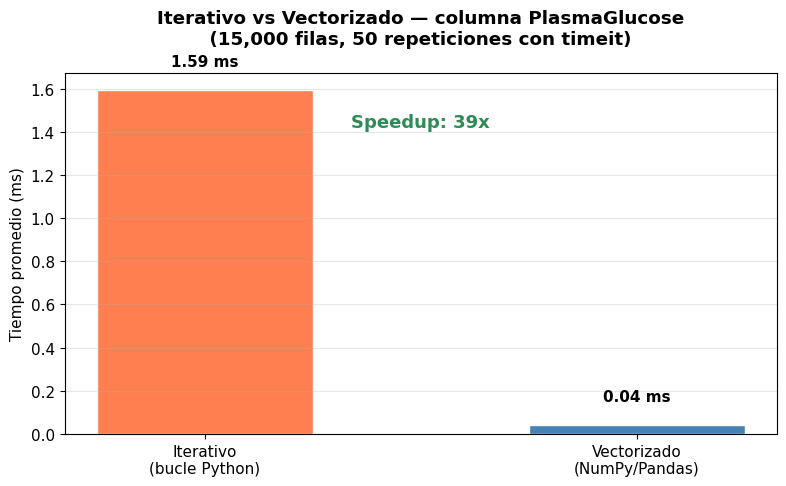


Interpretación: aunque ambas implementaciones tienen complejidad teórica O(n),
la versión vectorizada es 39x más rápida porque NumPy ejecuta
las operaciones en C compilado, eliminando el overhead del intérprete Python
en cada iteración. Esta diferencia se amplifica con datasets más grandes.


In [49]:
# Visualización de la comparación
fig, ax = plt.subplots(figsize=(8, 5))

implementaciones = ['Iterativo\n(bucle Python)', 'Vectorizado\n(NumPy/Pandas)']
tiempos_ms = [t_iter * 1000, t_vect * 1000]
colores_bar = ['coral', 'steelblue']

barras = ax.bar(implementaciones, tiempos_ms, color=colores_bar, edgecolor='white', width=0.5)

for barra, t in zip(barras, tiempos_ms):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1, f'{t:.2f} ms', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Tiempo promedio (ms)')
ax.set_title(f'Iterativo vs Vectorizado — columna {col_test}\n ({len(df_pipeline):,} filas, {n_reps} repeticiones con timeit) \n', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.5, 0.85, f'Speedup: {speedup:.0f}x', transform=ax.transAxes, ha='center', fontsize=13, color='seagreen', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"""\nInterpretación: aunque ambas implementaciones tienen complejidad teórica O(n),
la versión vectorizada es {speedup:.0f}x más rápida porque NumPy ejecuta
las operaciones en C compilado, eliminando el overhead del intérprete Python
en cada iteración. Esta diferencia se amplifica con datasets más grandes.""")


<a id="seccion-9"></a>

---
## 9. Documentación de arquitectura

### Componentes y responsabilidades

| Componente | Tipo | Responsabilidad | Principio POO |
|---|---|---|---|
| `Transformador` | Clase abstracta (ABC) | Define el contrato: `aplicar(df)` | Herencia |
| `ExcluirColumna` | Clase concreta | Excluir columnas sin valor predictivo | Herencia + Polimorfismo |
| `EliminarDuplicados` | Clase concreta | Verificar integridad del dataset | Herencia + Polimorfismo |
| `ImputarMediana` | Clase concreta | Imputar NA con mediana | Herencia + Polimorfismo |
| `NormalizarMinMax` | Clase concreta | Escalar features a [0,1] | Herencia + Polimorfismo |
| `Pipeline` | Clase (composición) | Orquestar etapas en orden | Composición + Polimorfismo |
| `AnalizadorDiabetes` | Clase (encapsulamiento) | Análisis exploratorio avanzado | Encapsulamiento |
| `_merge_sort_recursivo()` | Función recursiva | Ordenar features por correlación | — |

### Decisiones de diseño

**¿Por qué ABC para Transformador?** Garantiza que toda clase que herede de `Transformador` implemente `aplicar()`. Sin ABC, alguien podría crear una clase hija que "olvide" implementar el método y el error aparecería en tiempo de ejecución. Con ABC, aparece al instanciar.

**¿Por qué Pipeline usa composición?** Porque el pipeline "tiene" etapas, no "es" una etapa. La composición es más flexible: permite cambiar las etapas en tiempo de ejecución sin modificar la clase.

**¿Por qué atributos con guion bajo (`_df`, `_resultados`)?** El guion bajo señala que son atributos protegidos. Python no impide el acceso, pero por convención indica que no deben modificarse desde fuera de la clase.

### Escalabilidad

La arquitectura escala en F4 de la siguiente manera:
- Agregar una nueva transformación = crear una clase que herede de `Transformador`.
- Agregar un nuevo análisis = agregar un método a `AnalizadorDiabetes`.
- El `Pipeline` puede recibir la lista de etapas como configuración externa.

In [50]:
# Medición de complejidad espacial con tracemalloc
print("COMPLEJIDAD ESPACIAL — tracemalloc\n")

for nombre, func in [
    ("Pipeline (3 etapas)",
     lambda: Pipeline([EliminarDuplicados(), ImputarMediana(),
                       NormalizarMinMax()]).ejecutar(df.copy())),
    ("AnalizadorDiabetes.calcular_estadisticos_por_clase()",
     lambda: AnalizadorDiabetes(df, FEATURES, TARGET)
             .calcular_estadisticos_por_clase()),
    ("AnalizadorDiabetes.calcular_correlaciones()",
     lambda: AnalizadorDiabetes(df, FEATURES, TARGET)
             .calcular_correlaciones()),
]:
    tracemalloc.start()
    func()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"  {nombre}")
    print(f"    Pico de memoria: {peak/1024:.0f} KB\n")

COMPLEJIDAD ESPACIAL — tracemalloc

Pipeline iniciado — 3 etapas

Etapa 1/3: EliminarDuplicados()
  [EliminarDuplicados] 0 duplicados eliminados ✓
Etapa 2/3: ImputarMediana()
  [ImputarMediana] 0 valores imputados ✓
Etapa 3/3: NormalizarMinMax()
  [NormalizarMinMax] 8 columnas normalizadas ✓

Pipeline completado ✓  →  15,000 × 9
  Pipeline (3 etapas)
    Pico de memoria: 4243 KB

AnalizadorDiabetes inicializado ✓
  Filas    : 15,000
  Features : 8
  Target   : 'Diabetic'
  AnalizadorDiabetes.calcular_estadisticos_por_clase()
    Pico de memoria: 1577 KB

AnalizadorDiabetes inicializado ✓
  Filas    : 15,000
  Features : 8
  Target   : 'Diabetic'
  AnalizadorDiabetes.calcular_correlaciones()
    Pico de memoria: 3305 KB



<a id="seccion-10"></a>

---
## 10. Resumen y proyección


In [51]:
print("RESUMEN DEL NOTEBOOK — SUMATIVA 3 \n")
resumen = {
    'Componente': [
        'Dataset procesado de F2 (diabetes_clean.csv)',
        'Clase abstracta Transformador (ABC)',
        'ExcluirColumna (herencia)',
        'EliminarDuplicados (herencia)',
        'ImputarMediana (herencia)',
        'NormalizarMinMax (herencia)',
        'Pipeline (composición + polimorfismo)',
        'Validación: casos normal, límite y excepción',
        'AnalizadorDiabetes (encapsulamiento)',
        'Merge sort recursivo O(p·log p)',
        'Mediciones con timeit (5 tamaños)',
        'Comparación iterativo vs vectorizado',
        'Complejidad espacial con tracemalloc',
    ],
    'Estado': ['✓'] * 13
}
print(pd.DataFrame(resumen).to_string(index=False))

RESUMEN DEL NOTEBOOK — SUMATIVA 3 

                                  Componente Estado
Dataset procesado de F2 (diabetes_clean.csv)      ✓
         Clase abstracta Transformador (ABC)      ✓
                   ExcluirColumna (herencia)      ✓
               EliminarDuplicados (herencia)      ✓
                   ImputarMediana (herencia)      ✓
                 NormalizarMinMax (herencia)      ✓
       Pipeline (composición + polimorfismo)      ✓
Validación: casos normal, límite y excepción      ✓
        AnalizadorDiabetes (encapsulamiento)      ✓
             Merge sort recursivo O(p·log p)      ✓
           Mediciones con timeit (5 tamaños)      ✓
        Comparación iterativo vs vectorizado      ✓
        Complejidad espacial con tracemalloc      ✓


### Proyección a F4

- Extender el `Pipeline` con una etapa de **selección de features** basada en el ranking obtenido.
- Incorporar un **clasificador** como etapa final del pipeline (`EtapaClasificacion`).
- Agregar validación cruzada y métricas de evaluación como nuevos métodos de `AnalizadorDiabetes`.
- Migrar las clases a `src/` como módulos importables por todos los notebooks del proyecto.

### Bibliografía (APA 7)

UNAB. (2026a). *Programa de asignatura MCDIA500 — Programación para la Ciencia de Datos*. Universidad Andrés Bello.

UNAB. (2026b). *Guía de desarrollo — Sumativa 3 (Fase 3)*. MCDIA500, Universidad Andrés Bello.

McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media. https://wesmckinney.com/book/

VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly Media. https://jakevdp.github.io/PythonDataScienceHandbook/

Ramalho, L. (2022). *Fluent Python* (2nd ed.). O'Reilly Media.
